## TopoSplit Models

Generate forcing data using 4 separate models

In [1]:
# libraries
import os
import glob
import numpy as np
from datetime import datetime, timedelta
import math as m

from netCDF4 import Dataset

from snobedo.input import HrrrParameter, SmrfTopo
from snobedo.shortwave import TopoShade
from snobedo.input import SmrfTopo

import matplotlib.pyplot as plt

from topocalc.horizon import horizon
from topocalc.shade import shade

# cusotm functions
import topo_split as tsw

In [2]:
# paths
UVU_OLSON_HOME = '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/'
HRRR_DATA = UVU_OLSON_HOME + 'HRRR_2022/'
ERW_TOPO_FILE = UVU_OLSON_HOME + 'isnobal-data/ERW_topo.nc'

### HRRR file (single)

In [3]:
# Set the PROJ_LIB environment variable
os.environ['PROJ_LIB'] = '/uufs/chpc.utah.edu/common/home/skiles-group1/jmeyer/conda/envs/smeshr/share/proj' 
hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, HRRR_DATA + 'hrrr.20220301/hrrr.t09z.wrfsfcf06.grib2', 'cubic')

### For single moment

In [4]:
# load terrain variables
dem, sky_view_factor, topo_shade = tsw.static_topo_vars(ERW_TOPO_FILE)

# calculate solar geometry (FUll day)
azimuth, zenith, incidence_angles, illumination = tsw.hrrr_solar_geom(hrrr_dswrf, topo_shade)

# run models
ghi, dsw1, dsw2, dsw3 = tsw.toposplitModels4(hrrr_dswrf, zenith, azimuth, incidence_angles, illumination, sky_view_factor, topo_shade)

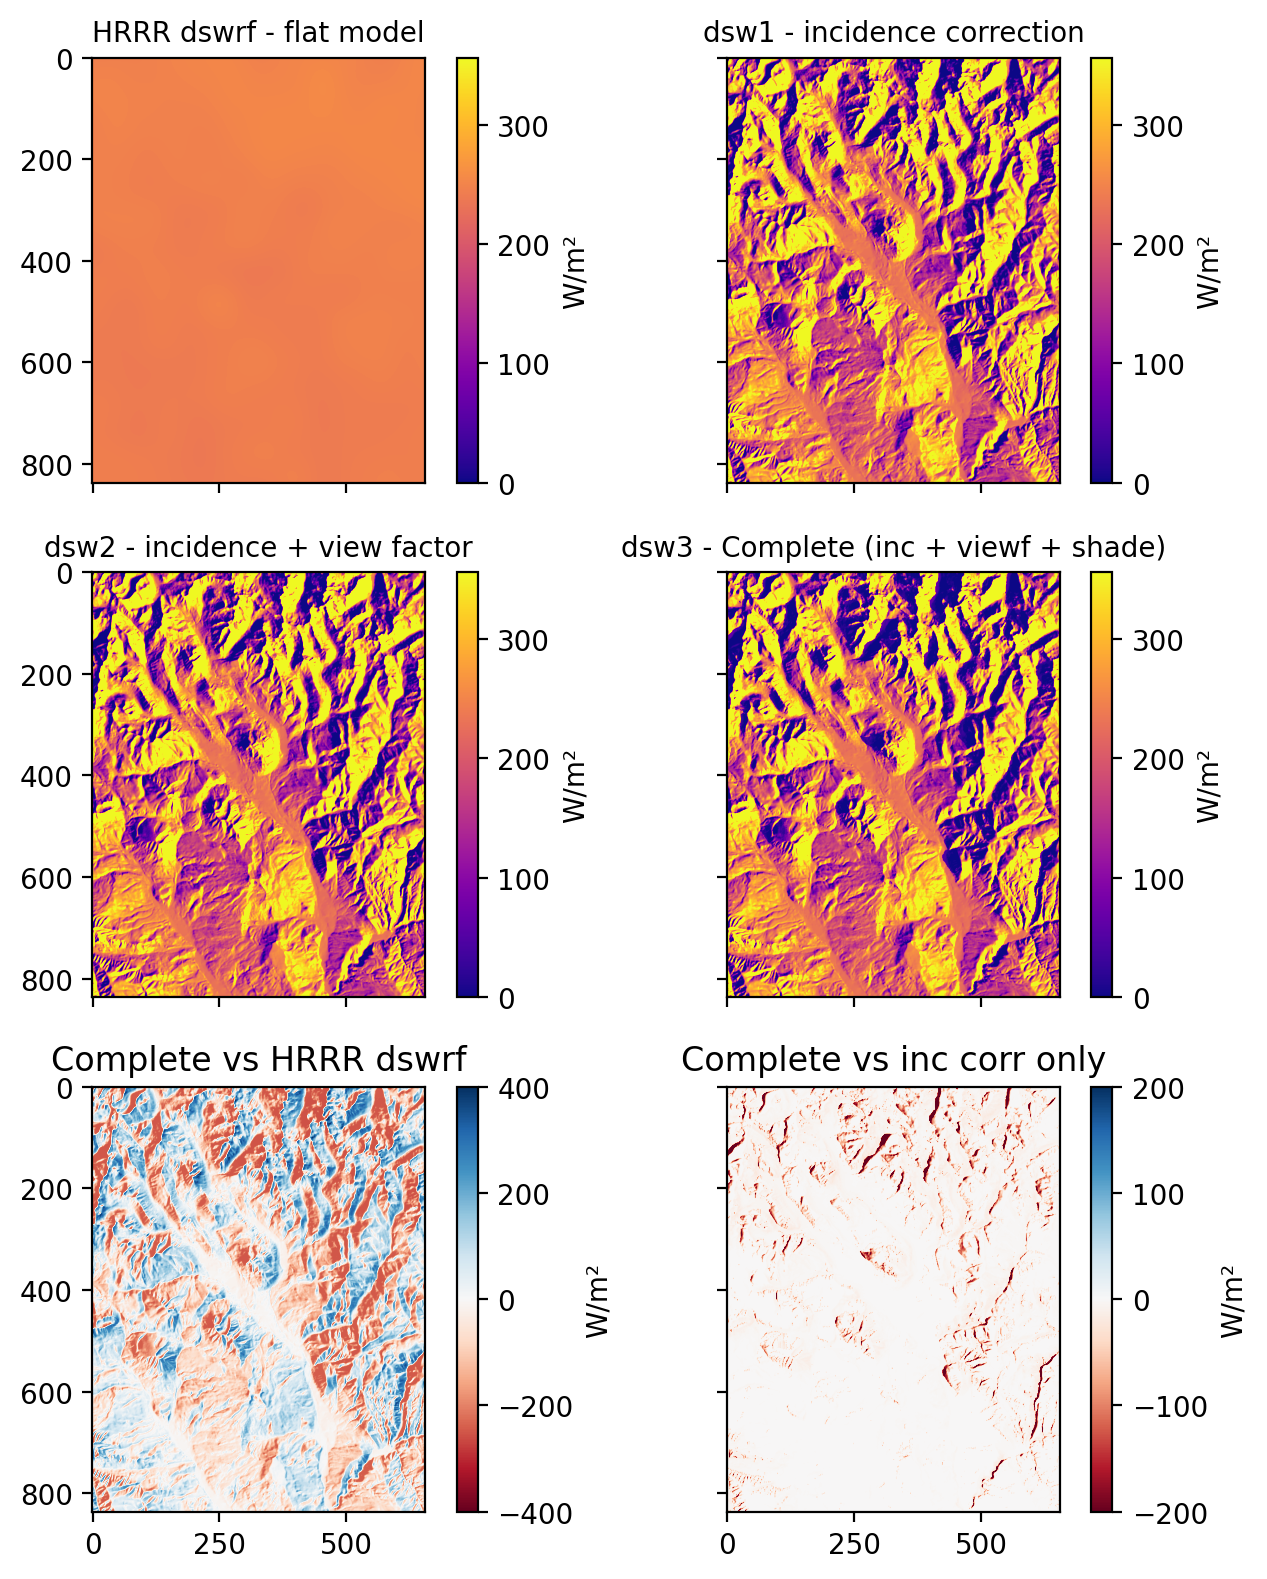

In [5]:
# PLOT MODELS
fig, ax = plt.subplots(ncols=2, nrows=3, dpi=200, figsize=(7,8), sharex=True, sharey=True)
ax = ax.flatten()

axes_args = dict(cmap='plasma', vmax=(ghi.max() + 100), vmin=0)
title_args = dict(fontsize=10)

# Plot and create colorbars
im0 = ax[0].imshow(ghi, **axes_args)
ax[0].set_title('HRRR dswrf - flat model', **title_args)
fig.colorbar(im0, ax=ax[0], label="W/m²")

im1 = ax[1].imshow(dsw1, **axes_args)
ax[1].set_title('dsw1 - incidence correction', **title_args)
fig.colorbar(im1, ax=ax[1], label="W/m²")

im2 = ax[2].imshow(dsw2, **axes_args)
ax[2].set_title('dsw2 - incidence + view factor', **title_args)
fig.colorbar(im2, ax=ax[2], label="W/m²")

im3 = ax[3].imshow(dsw3, **axes_args)
ax[3].set_title('dsw3 - Complete (inc + viewf + shade)', **title_args)
fig.colorbar(im3, ax=ax[3], label="W/m²")

im4 = ax[4].imshow(dsw2 - ghi, cmap='RdBu', vmin=-400, vmax=400)
ax[4].set_title('Complete vs HRRR dswrf')
fig.colorbar(im4, ax=ax[4], label="W/m²")

im5 = ax[5].imshow(dsw3 - dsw1, cmap='RdBu', vmin=-200, vmax=200)
ax[5].set_title('Complete vs inc corr only')
fig.colorbar(im5, ax=ax[5], label="W/m²")

plt.tight_layout()
plt.show()

## Stack for full HRRR day

In [6]:

# issue with handling days that cross over to next HRRR grib?
# i.e. make sure that HRRR date matches with zenith etc.


Wrapper for single day - works for March 1st but may not work for days later in season when sun is up at early UTC hours...

In [7]:
# run function
# SAVES ncdf file for single HRRR day
tsw.toposplit_day_wrap_to_netcdf(
    ERW_TOPO_FILE,
    HRRR_DIR = HRRR_DATA + 'hrrr.20220302',
    output_root_dir = UVU_OLSON_HOME + 'hrrr_toposplit/'
)

# NEED new function to account for crossover in UTC hours

/uufs/chpc.utah.edu/common/home/u1037042/Documents/src/snowtools/snowsol-24/hrrr-shortwave-25/topo_split.py:105: RuntimeWarning: divide by zero encountered in divide
  k = hrrr_dswrf.grib_file.GetRasterBand(11).ReadAsArray() / hrrr_dswrf.grib_file.GetRasterBand(12).ReadAsArray()
/uufs/chpc.utah.edu/common/home/u1037042/Documents/src/snowtools/snowsol-24/hrrr-shortwave-25/topo_split.py:109: RuntimeWarning: invalid value encountered in multiply
  dni0 = ((ghi * (1-k)) / (np.cos(zenith[hour]*m.pi/180))) * incidence_angles[hour]


[!] Error processing /uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/HRRR_2022/hrrr.20220302/hrrr.t00z.wrfsfcf06.grib2: '2022-03-02 06:00'


/uufs/chpc.utah.edu/common/home/u1037042/Documents/src/snowtools/snowsol-24/hrrr-shortwave-25/topo_split.py:116: RuntimeWarning: invalid value encountered in multiply
  dni = ((ghi * (1-k)) / (np.cos(zenith[hour]*m.pi/180))) * illumination[hour]


[✓] Processed 2022-03-02 07:00
[✓] Processed 2022-03-02 08:00
[✓] Processed 2022-03-02 09:00
[✓] Processed 2022-03-02 10:00
[✓] Processed 2022-03-02 11:00
[✓] Processed 2022-03-02 12:00
[✓] Processed 2022-03-02 13:00
[✓] Processed 2022-03-02 14:00
[✓] Processed 2022-03-02 15:00
[✓] Processed 2022-03-02 16:00
[✓] Processed 2022-03-02 17:00
[✓] Processed 2022-03-02 18:00
[✓] Processed 2022-03-02 19:00
[✓] Processed 2022-03-02 20:00
[✓] Processed 2022-03-02 21:00
[✓] Processed 2022-03-02 22:00
[✓] Processed 2022-03-02 23:00
[✓] Processed 2022-03-03 00:00
[✓] Processed 2022-03-03 01:00
[✓] Processed 2022-03-03 02:00
[✓] Processed 2022-03-03 03:00
[✓] Processed 2022-03-03 04:00
[✓] Processed 2022-03-03 05:00
[✓] Saved: /uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/hrrr_toposplit/hrrr_dswrf/ghi_20220302.nc
[✓] Saved: /uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/hrrr_toposplit/hrrr_dsw1/dsw1_20220302.nc
[✓] Saved: /uufs/chpc.utah.edu/common/home/uvu-group1/olson/sno

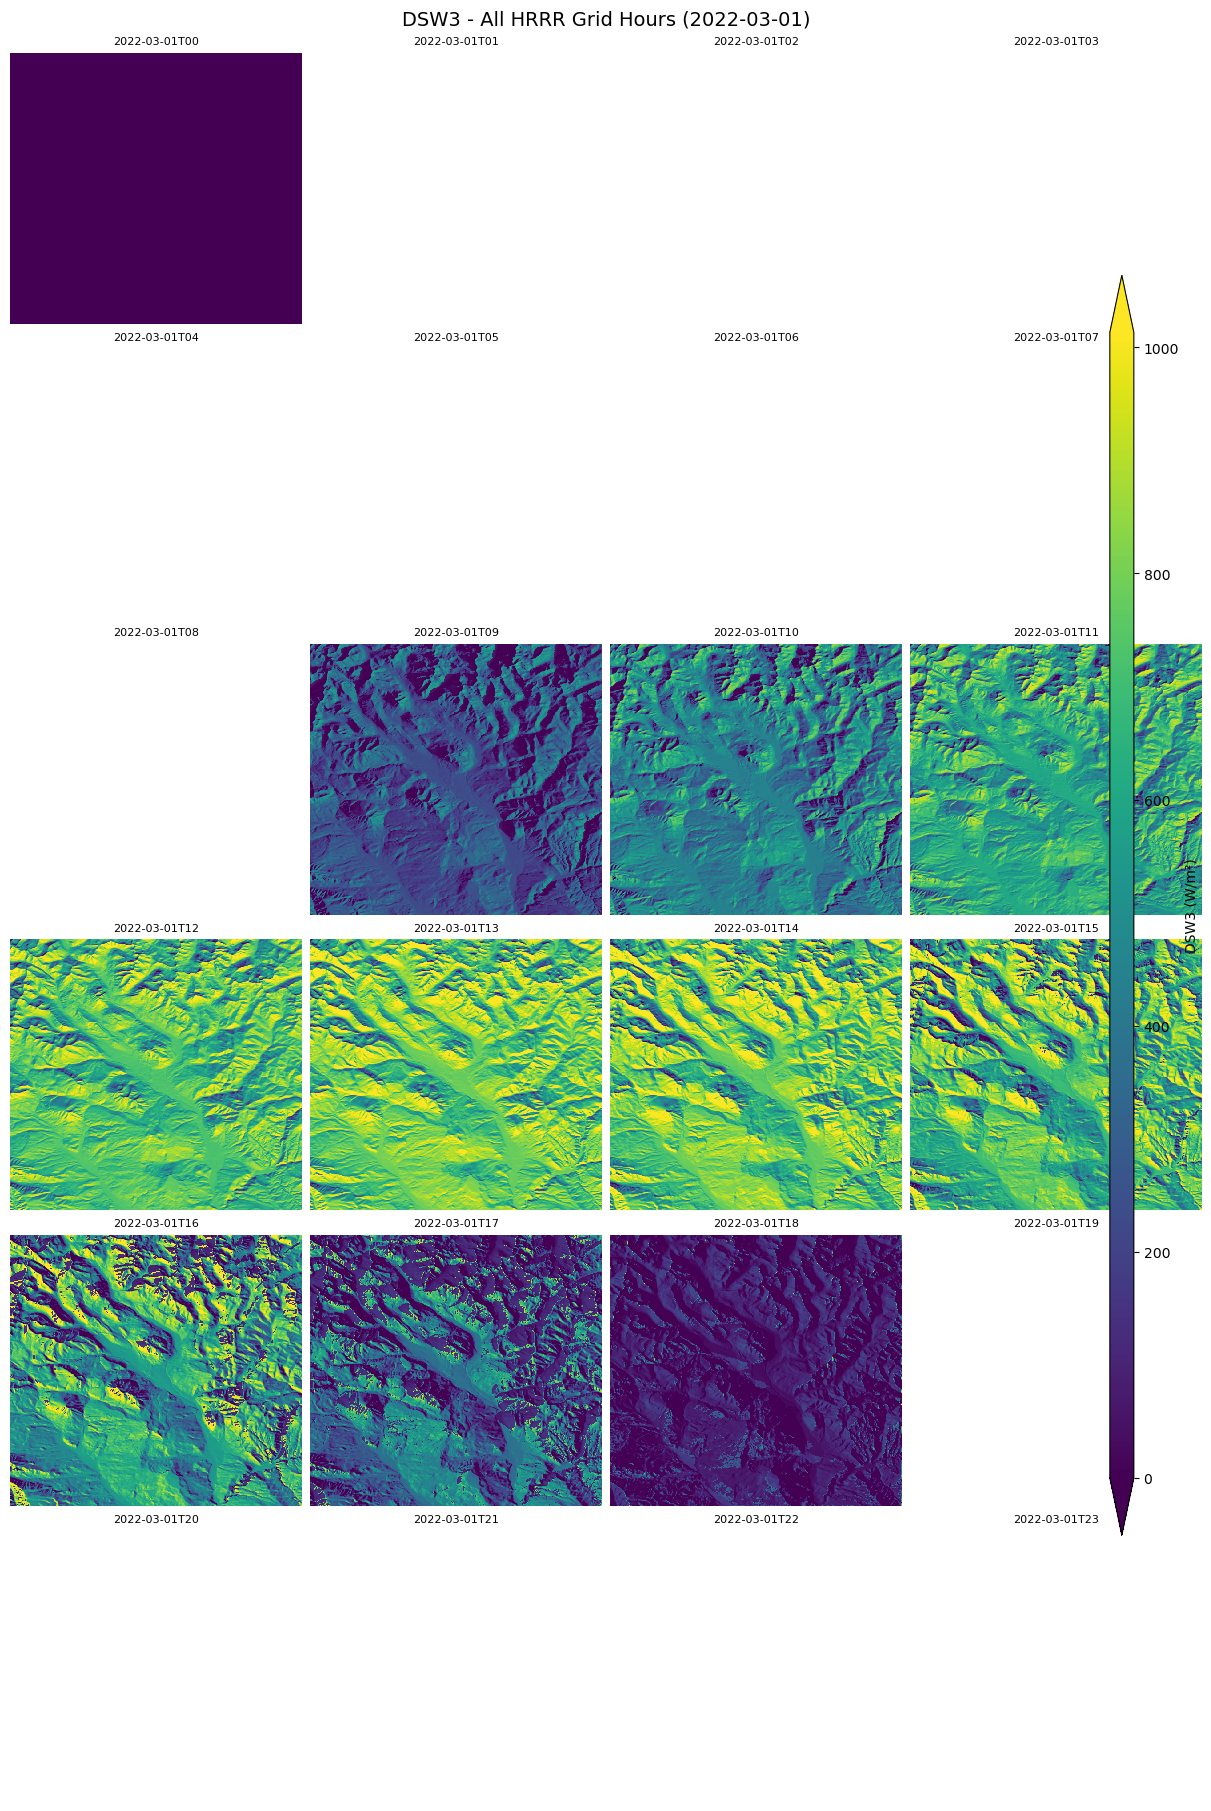

In [9]:
import xarray as xr

# read in files and variables
file_path = UVU_OLSON_HOME + 'hrrr_toposplit/' + 'hrrr_dsw3/dsw3_20220301.nc'
var_name = 'dsw3'  # or 'ghi', 'dsw1', 'dsw2'
ncols = 4
cmap = 'viridis'

# load all hours
ds = xr.open_dataset(file_path)
data = ds[var_name]

# flip for correct orientation
data_flipped = data[:, ::-1, :]

# colorscale
vmin = np.nanpercentile(data_flipped, 2)
vmax = np.nanpercentile(data_flipped, 98)

# create subgrids
nt = data_flipped.time.size
nrows = int(np.ceil(nt / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3), constrained_layout=True)
axes = axes.flatten()

# plot each hour in file
for i in range(nt):
    ax = axes[i]
    im = data_flipped.isel(time=i).plot(
        ax=ax, cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax
    )
    time_str = np.datetime_as_string(data_flipped.time[i].values, unit='h')
    ax.set_title(f"{time_str}", fontsize=8)
    ax.axis('off')

# turn off blank axes
for j in range(nt, len(axes)):
    axes[j].axis('off')

# colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label=f'{var_name.upper()} (W/m²)', extend='both')

plt.suptitle(f"{var_name.upper()} - All HRRR Grid Hours ({ds.time[0].dt.date.values})", fontsize=14)
plt.show()


## New Day Wrapper for handling crossover in daylight hours between HRRR days

## Full Wrapper for all days of WY